|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Metaparameters (activations, optimizers)<h1>|
|<h2>Lecture:</h2>|<h1><b>The "wine quality" dataset<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
### import libraries

# for DL modeling
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# for number-crunching
import numpy as np
import scipy.stats as stats

# for dataset management
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import and process the data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

data = pd.read_csv(url,sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
# describe the data
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
# list number of unique values per column

for i in data.keys():
  print(f'{i} has {len(np.unique(data[i]))} unique values')

fixed acidity has 96 unique values
volatile acidity has 143 unique values
citric acid has 80 unique values
residual sugar has 91 unique values
chlorides has 153 unique values
free sulfur dioxide has 60 unique values
total sulfur dioxide has 144 unique values
density has 436 unique values
pH has 89 unique values
sulphates has 96 unique values
alcohol has 65 unique values
quality has 6 unique values


<Figure size 1000x1000 with 0 Axes>

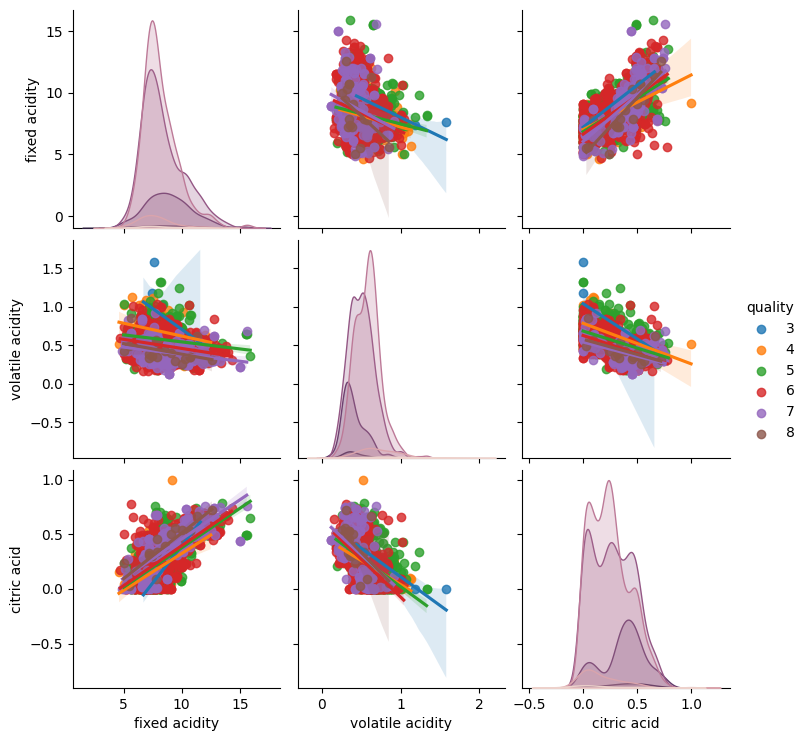

In [5]:
# pairwise plots
cols2plot = ['fixed acidity','volatile acidity','citric acid','quality']
fig = plt.figure(figsize=(10,10))
sns.pairplot(data[cols2plot],kind='reg',hue='quality')
plt.show()

/tmp/ipykernel_4433/1692729530.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)


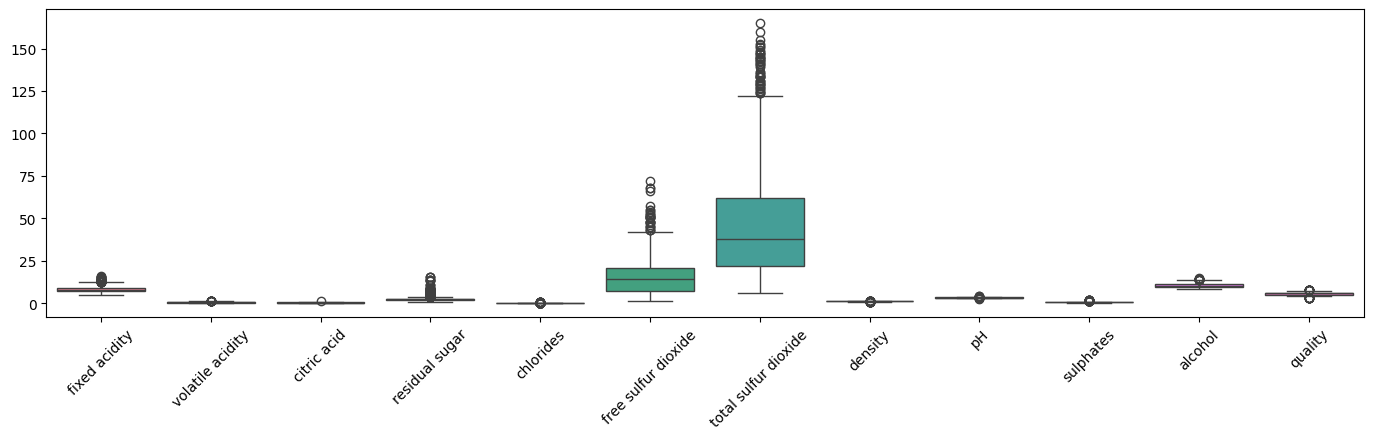

In [6]:
# plot some data
# remove rows with outliers
data = data[data['total sulfur dioxide']<200]

fig,ax = plt.subplots(1,figsize=(17,4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
plt.show()

In [7]:
### z-score all variables except for quality

# find the columns we want to normalize (all except quality)
cols2zscore = data.keys()
cols2zscore = cols2zscore.drop('quality')

# z-score (written out for clarity)
for col in cols2zscore:
  meanval   = np.mean(data[col])
  stdev     = np.std(data[col],ddof=1)
  data[col] = (data[col]-meanval) / stdev

# can also do more compactly
#data[cols2zscore] = data[cols2zscore].apply(stats.zscore)

data.describe()

/tmp/ipykernel_4433/3096180966.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = (data[col]-meanval) / stdev


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1.597000e+03,1597.000000
mean,1.779694e-17,1.156801e-16,1.779694e-17,-7.563699e-17,-1.512740e-16,-1.779694e-17,-7.118775e-17,-8.357442e-14,3.025479e-16,8.008622e-17,-5.872989e-16,5.634314
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.806630
min,-2.135419e+00,-2.280048e+00,-1.391387e+00,-1.168783e+00,-1.604073e+00,-1.422392e+00,-1.262186e+00,-3.545821e+00,-3.708218e+00,-1.936711e+00,-1.898626e+00,3.000000
25%,-7.003882e-01,-7.715838e-01,-9.283861e-01,-4.524372e-01,-3.720247e-01,-8.476045e-01,-7.594598e-01,-6.109478e-01,-6.585382e-01,-6.390204e-01,-8.650444e-01,5.000000
50%,-2.411785e-01,-4.528645e-02,-5.382836e-02,-2.375335e-01,-1.808448e-01,-1.770192e-01,-2.567340e-01,-6.214425e-04,-9.670044e-03,-2.261189e-01,-2.073106e-01,6.000000
75%,5.050372e-01,6.251419e-01,7.692848e-01,4.900487e-02,5.281955e-02,4.935662e-01,4.973546e-01,5.778618e-01,5.743113e-01,4.227263e-01,6.383472e-01,6.000000
max,4.350918e+00,5.876831e+00,3.753070e+00,9.289866e+00,1.112001e+01,5.379259e+00,3.733652e+00,3.682565e+00,4.532407e+00,7.913939e+00,4.208902e+00,8.000000


/tmp/ipykernel_4433/328671079.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)


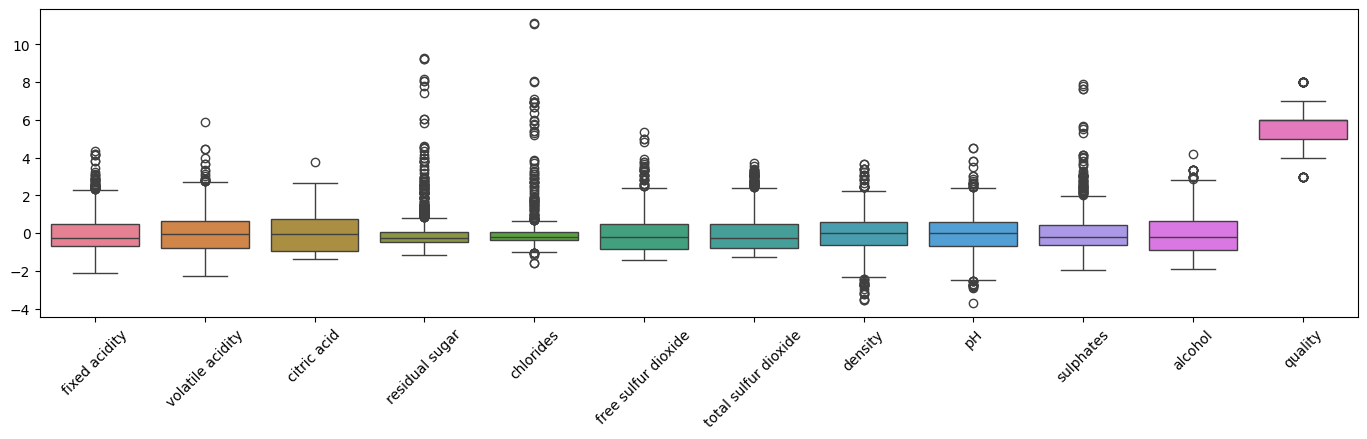

In [8]:
# check the plot again
fig,ax = plt.subplots(1,figsize=(17,4))
ax = sns.boxplot(data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
plt.show()

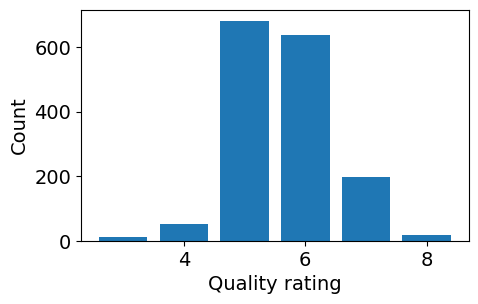

/tmp/ipykernel_4433/4078136813.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'boolQuality'] = 0


,quality,boolQuality
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0
...,...,...
1594,5,0
1595,6,1
1596,6,1
1597,5,0


In [9]:
# distribution quality values
fig = plt.figure(figsize=(5,3))
plt.rcParams.update({'font.size': 14}) # increase font size in the figure

counts = data['quality'].value_counts()
plt.bar(list(counts.keys()),counts)
plt.xlabel('Quality rating')
plt.ylabel('Count')
plt.show()

# create a new column for binarized (boolean) quality
data.loc[:,'boolQuality'] = 0
# ata.loc[data['quality']<6,'boolQuality'] = 0 # implicit in the code! just here for clarity
data.loc[data['quality']>5,'boolQuality'] = 1

data[['quality','boolQuality']]

# Re-organize the data: train/test in DataLoaders

In [10]:
# convert from pandas dataframe to tensor
dataT  = torch.Tensor( data[cols2zscore].values ).float()
labels = torch.Tensor( data['boolQuality'].values ).float()
 
# we'll actually need the labels to be a "tensor"
labels = labels[:,None]

print( dataT.shape )
print( labels.shape )

torch.Size([1597, 11])
torch.Size([1597, 1])


<Figure size 1000x1000 with 0 Axes>

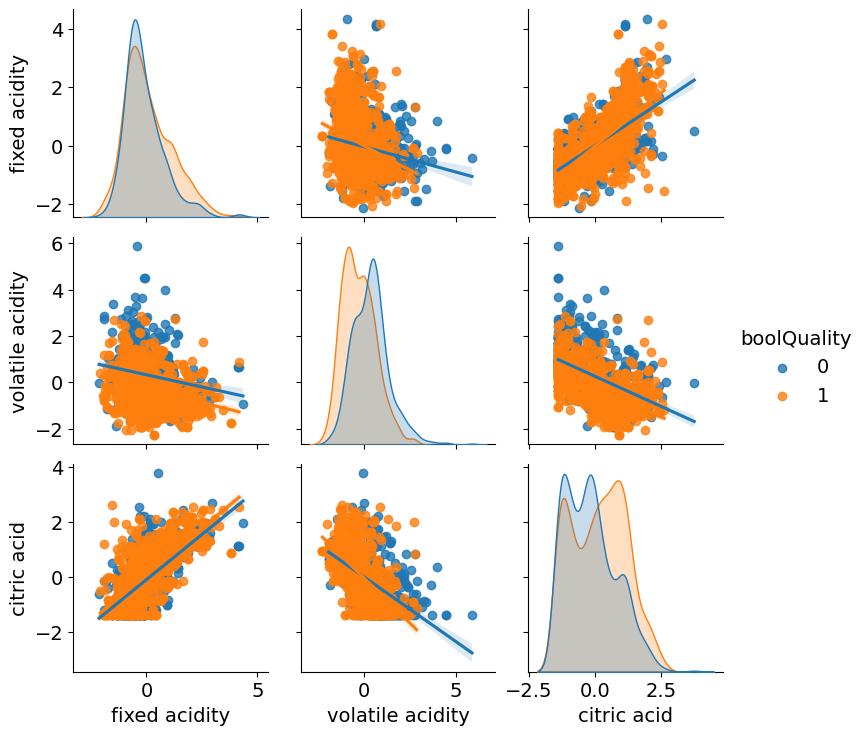

In [11]:
# pairwise plots
cols2plot = ['fixed acidity','volatile acidity','citric acid','boolQuality']
fig = plt.figure(figsize=(10,10))
sns.pairplot(data[cols2plot],kind='reg',hue='boolQuality')
plt.show()

In [12]:
def split_dataset(data, labels, batchsize:int=64, test_fraction=.2):
    """
    Splits the dataset into training and testing sets.

    Parameters:
    data (torch.Tensor): The input data tensor.
    labels (torch.Tensor): The labels tensor.
    batchsize (int): The batch size for the DataLoader.
    test_fraction (float): The fraction of the dataset to be used as the test set.

    Returns:
    train_data (torch.Tensor): Training data tensor.
    test_data (torch.Tensor): Testing data tensor.
    train_labels (torch.Tensor): Training labels tensor.
    test_labels (torch.Tensor): Testing labels tensor.
    """
    # use scikitlearn to split the data
    train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=test_fraction)

    # then convert them into PyTorch Datasets (note: already converted to tensors)
    train_data = TensorDataset(train_data,train_labels)
    test_data  = TensorDataset(test_data,test_labels)

    # finally, translate into dataloader objects
    train_loader = DataLoader(train_data,batch_size=int(batchsize),shuffle=True,drop_last=True)
    test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])
    
    return train_loader, test_loader

# Test split_dataset function
train_loader, test_loader = split_dataset(dataT, labels, batchsize=64, test_fraction=0.2)

# check sizes of data batches
for i, (X,y) in enumerate(train_loader):
  print(f'train batch {i}: ', X.shape,y.shape)
  if i > 2: break
  
for i, (X,y) in enumerate(test_loader):
  print('test: ', X.shape,y.shape)
  if i > 2: break


train batch 0:  torch.Size([64, 11]) torch.Size([64, 1])
train batch 1:  torch.Size([64, 11]) torch.Size([64, 1])
train batch 2:  torch.Size([64, 11]) torch.Size([64, 1])
train batch 3:  torch.Size([64, 11]) torch.Size([64, 1])
test:  torch.Size([320, 11]) torch.Size([320, 1])


In [13]:
class theModelClass(nn.Module):
  def __init__(self, nIn:int=11, nOut:int=1, nUnit:int=128, nHidden:int=1, dropoutRate:float=.0):
    super().__init__()

    ### layers
    self.input  = nn.Linear(  nIn,nUnit)
    self.hidden = nn.ModuleDict()
    for i in range(nHidden):
      self.hidden[f'hidden{i}'] = nn.Linear(nUnit,nUnit)
    self.output = nn.Linear(nUnit, nOut)

    # parameters
    self.dr = dropoutRate

  # forward pass
  def forward(self,x):
    # Input layer
    x = F.relu( self.input(x) )
    x = F.dropout(x,p=self.dr,training=self.training)

    # dropout after input layer
    for i in range(len(self.hidden)):
      x = F.relu( self.hidden[f'hidden{i}'](x) )
      x = F.dropout(x,p=self.dr,training=self.training)
      
    # Output layer
    x = self.output(x)
    return x
  
# test the model
tmpnet = theModelClass()
tmpdata = torch.randn((3,11))
yhat = tmpnet(tmpdata)
print(tmpdata)
print(yhat)

tensor([[ 1.8503, -1.2287,  1.0333,  0.4375,  0.1379, -1.5644, -0.6227, -0.2679,
          1.0424, -0.4922, -1.1705],
        [ 0.5421,  0.8699, -0.2252,  0.9101, -1.7141,  0.3423, -0.7117,  0.0446,
         -0.1235, -1.6443,  0.0919],
        [-0.1441, -1.4365, -0.3657, -1.2281, -0.6433, -1.6058, -2.1309, -1.0735,
         -3.1226,  1.2415,  2.1904]])
tensor([[-0.0882],
        [ 0.0748],
        [ 0.0636]], grad_fn=<AddmmBackward0>)


In [14]:
# a function that creates the ANN model
def createANewModel(dropoutrate:float=0.0, lerningrate:float=.001):
  net = theModelClass(dropoutRate=dropoutrate)
  # lossfun = nn.CrossEntropyLoss()
  lossfun = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.SGD(net.parameters(),lr=lerningrate)
  return net,lossfun,optimizer

In [15]:
# a function that trains the ANN model
def trainTheModel(net, lossfun, optimizer, train_loader, test_loader, numepochs:int=100):
  # initialize accuracies as empties (not storing losses here)
  trainAcc = []
  testAcc  = []
  losses   = []
  # loop over epochs
  for epochi in range(numepochs):

    # switch learning on
    net.train()

    # loop over training data batches
    batchAcc = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # compute training accuracy just for this batch
      batchAcc.append( 100*torch.mean(((yHat>0)==y).float()).item() )
      batchLoss.append(loss.item())
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )
    losses.append( np.mean(batchLoss) )

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test_loader
    with torch.no_grad():
      yHat = net(X)
      testAcc.append( 100*torch.mean(((yHat>0)==y).float()).item() )

  return trainAcc,testAcc,losses

# Run Experiment

In [16]:
batch_sizes = 2**np.arange(1,10,2)
batch_compute_time = np.zeros(batch_sizes.shape)

numepochs = 1000
trainAccPerBatchSize = np.zeros( (len(batch_sizes),numepochs) )
testAccPerBatchSize = np.zeros( (len(batch_sizes),numepochs) )
lossesPerBatchSize = np.zeros( (len(batch_sizes),numepochs) )
for i, bs in enumerate(batch_sizes):
    start_time = time.monotonic()
    # Split data
    train_loader, test_loader = split_dataset(dataT, labels, batchsize=int(bs), test_fraction=0.2)

    # Create a model
    dropoutrate = .0
    net,lossfun,optimizer = createANewModel(dropoutrate=dropoutrate, lerningrate=.01)

    # train the model
    trainAcc,testAcc,losses = trainTheModel(
        net, lossfun, optimizer, train_loader, test_loader, numepochs=numepochs)
    trainAccPerBatchSize[i,:] = np.array(trainAcc)
    testAccPerBatchSize[i,:]  = np.array(testAcc)
    lossesPerBatchSize[i,:]   = np.array(losses)
    batch_compute_time[i] = time.monotonic() - start_time

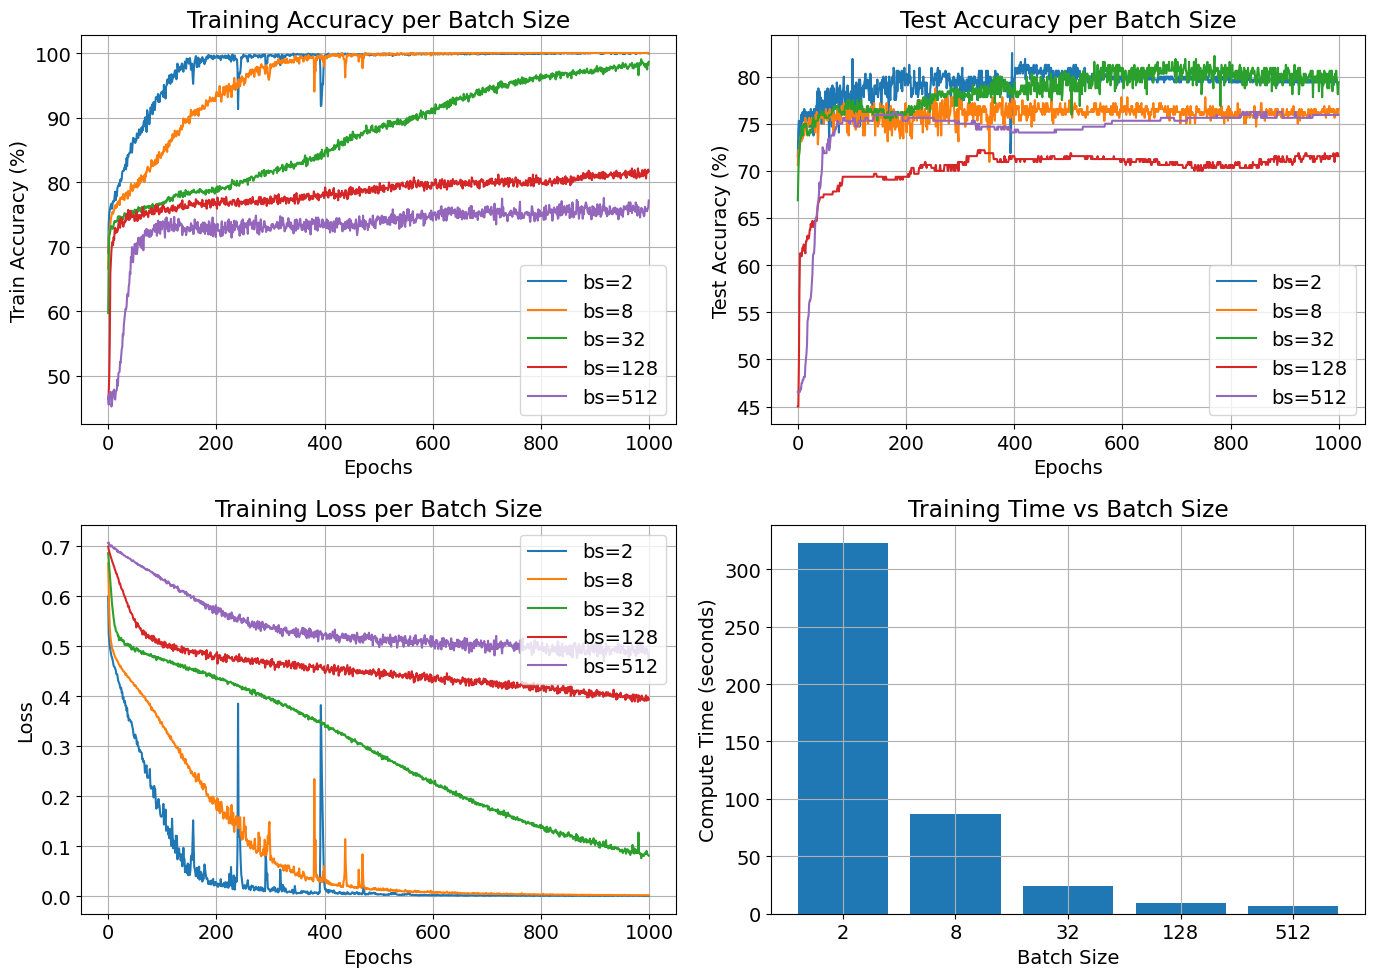

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Train accuracy
for i, bs in enumerate(batch_sizes):
    ax[0, 0].plot(trainAccPerBatchSize[i, :], label=f'bs={bs}')
ax[0, 0].set_xlabel('Epochs')
ax[0, 0].set_ylabel('Train Accuracy (%)')
ax[0, 0].set_title('Training Accuracy per Batch Size')
ax[0, 0].legend(loc='best')
ax[0, 0].grid(True)

# Test accuracy
for i, bs in enumerate(batch_sizes):
    ax[0, 1].plot(testAccPerBatchSize[i, :], label=f'bs={bs}')
ax[0, 1].set_xlabel('Epochs')
ax[0, 1].set_ylabel('Test Accuracy (%)')
ax[0, 1].set_title('Test Accuracy per Batch Size')
ax[0, 1].legend(loc='best')
ax[0, 1].grid(True)

# Loss
for i, bs in enumerate(batch_sizes):
    ax[1, 0].plot(lossesPerBatchSize[i, :], label=f'bs={bs}')
ax[1, 0].set_xlabel('Epochs')
ax[1, 0].set_ylabel('Loss')
ax[1, 0].set_title('Training Loss per Batch Size')
ax[1, 0].legend(loc='best')
ax[1, 0].grid(True)

# Batch compute time
ax[1, 1].bar(range(len(batch_sizes)), batch_compute_time, tick_label=batch_sizes)
ax[1, 1].set_xlabel('Batch Size')
ax[1, 1].set_ylabel('Compute Time (seconds)')
ax[1, 1].set_title('Training Time vs Batch Size')
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()